In [3]:
import torch
# from torch.autograd import grad
# from torch.autograd.functional import jacobian, hessian
import matplotlib.pyplot as plt
from functools import partial

In [4]:
def double_pend_KE(q, qd):
    m = 1.0  # mass of the pendulum
    l = 1.0  # length of the pendulum
    g = 9.81  # acceleration due to gravity

    q1, q2 = q[:, 0], q[:, 1]
    qd1, qd2 = qd[:, 0], qd[:, 1]
    T1 = 0.5 * m * (l**2) * qd1**2
    T2 = 0.5 * m * (l**2) * (qd1**2 + 2 * qd1 * qd2 * torch.cos(q1 - q2) + qd2**2)
    T = T1 + T2
    return T

def double_pend_PE(q):
    m = 1.0  # mass of the pendulum
    l = 1.0  # length of the pendulum
    g = 9.81  # acceleration due to gravity
    q1, q2 = q[:, 0], q[:, 1]
    V = -2*m*g*l*torch.cos(q1) - m*g*l*torch.cos(q2)
    return V

def double_pendulum_lagrangian(q, qd):
    # Lagrangian is the difference between kinetic and potential energy
    return double_pend_KE(q, qd) - double_pend_PE(q)

In [5]:
def pendulum_KE(qd):
    # Constants
    m = 1.0  # mass of the pendulum
    l = 1.0  # length of the pendulum
    g = 9.81  # acceleration due to gravity
    # Kinetic energy formula for a pendulum
    # KE = 0.5 * m * (l * qd)^2
    KE = 0.5 * m * (l * qd)**2
    return KE

def pendulum_PE(q):
    # Constants
    m = 1.0  # mass of the pendulum
    l = 1.0  # length of the pendulum
    g = 9.81  # acceleration due to gravity
    # Potential energy formula for a pendulum
    # PE = m * g * (l - l * cos(q))
    PE = m * g * l * (1 - torch.cos(q))
    return PE

def pendulum_lagrangian(q, qd):
    # Lagrangian is the difference between kinetic and potential energy
    return pendulum_KE(qd) - pendulum_PE(q)

In [6]:
def lagrangian_dynamics(x, Lagrangian, state_dim):
    # derives the dynamics using just state information

    # d/dt(dL/dqd) - dL/dq = 0
    # d2L/dqd2 * qdd + d/dq(dL/dqd) * qd = dL/dq
    # qdd = (dL_dq - d/dq(dL/dqd) * qd) / d2L_dqd2
    # qdd = (G - C*qd) / M

    # q = x[:, :state_dim]
    # qd = x[:, state_dim:]

    # L:torch.Tensor = Lagrangian(q, qd)
    # L_sum = lambda Q, Qd: Lagrangian(Q, Qd).sum()

    # grad_func = grad
    # grad_args = {"create_graph": True, "allow_unused": True, "materialize_grads": True}

    # G, = grad_func(L.sum(), q, **grad_args)
    # # dLdqd, = grad_func(L.sum(), qd, **grad_args)
    # batch_idx = torch.arange(q.shape[0], device=q.device) 
    # M = hessian(partial(L_sum, q), qd, create_graph=True)
    # M = M[batch_idx, :, batch_idx, :]
    # # yields size (bs, vel_dim, bs, vel_dim), indexing gets back size (bs, vel_dim, vel_dim)
    # # C, = grad_func(dLdqd.sum(), q, **grad_args)
    # C = hessian(partial(L_sum, Qd=qd), q, create_graph=True)
    # C = C[batch_idx, :, batch_idx, :]
    # Minv = torch.linalg.pinv(M)
    # # import pdb; pdb.set_trace()
    # qdd = torch.bmm(Minv, (G - torch.bmm(C,qd[:,:,None])[:,:,0])[:,:,None])[:,:,0]

    q = x[:,:state_dim]
    qd = x[:,state_dim:]
    
    lagrangian = Lagrangian

    # Calculate Lagrangian
    L = lagrangian(q, qd)
    
    # Compute gradients (vectors)
    dL_dq = grad(L, q, create_graph=True)[0]  # ∂L/∂q    
    # Mass matrix: M = ∂²L/∂qd²
    M = hessian(lambda qd_input: lagrangian(q, qd_input), qd, create_graph=True)[:,:,0,:]
    
    # Coriolis matrix: C = ∂/∂q(∂L/∂qd)
    C = jacobian(lambda q_input: grad(lagrangian(q_input, qd), qd, create_graph=True)[0], q)[:,:,0,:]
    
    # Compute C*qd with a simple matrix multiplication
    C_qd = C @ qd.T
    
    # import pdb; pdb.set_trace()

    # Solve the system M * qdd = dL_dq - C_qd
    qdd = torch.linalg.solve(M, (dL_dq - C_qd[:,:,0]))
    
    return torch.cat([qd, qdd], dim=1)

# def lagrangian_dynamics_batched(x, Lagrangian, state_dim):
#     batch_size = x.shape[0]
#     q = x[:, :state_dim]
#     qd = x[:, state_dim:]
    
#     # Calculate Lagrangian for all batch elements
#     L = Lagrangian(q, qd)
    
#     # Compute gradients
#     dL_dq = grad(L.sum(), q, create_graph=True, allow_unused=True, materialize_grads=True)[0]  # ∂L/∂q
#     L_sum = lambda qd_input: Lagrangian(q, qd_input).sum() # Create helper function for Hessian calculation
#     M_full = hessian(L_sum, qd, create_graph=True) # Mass matrix: Full Hessian has shape [batch_size, state_dim, batch_size, state_dim]
#     batch_indices = torch.arange(batch_size, device=x.device)# Extract block-diagonal elements (the mass matrices for each batch element)
#     M = M_full[batch_indices, :, batch_indices, :]  # Shape: [batch_size, state_dim, state_dim]
    
#     # For the Coriolis term, we need the Jacobian of dL/dqd with respect to q
#     dL_dqd_sum = lambda q_input: grad(Lagrangian(q_input, qd).sum(), qd, create_graph=True, allow_unused=True)[0]
#     C_full = jacobian(dL_dqd_sum, q, create_graph=True)
    
#     # Extract the correct parts of the Jacobian
#     C = C_full[batch_indices, :, batch_indices, :]  # Shape: [batch_size, state_dim, state_dim]
    
#     # Compute C * qd for each batch element
#     # Each C[i] has shape [state_dim, state_dim], qd[i] has shape [state_dim]
#     C_qd = torch.bmm(C, qd.unsqueeze(-1)).squeeze(-1)  # Shape: [batch_size, state_dim]
    
#     # Solve M * qdd = dL_dq - C_qd for each batch element
#     rhs = dL_dq - C_qd  # Shape: [batch_size, state_dim]
    
#     # Using batched solve for all elements at once
#     qdd = torch.linalg.solve(M, rhs.unsqueeze(-1)).squeeze(-1)  # Shape: [batch_size, state_dim]

#     result = torch.cat([qd, qdd], dim=1)

#     # import pdb; pdb.set_trace() 
#     # print(result.device)

#     return result  # Shape: [batch_size, 2*state_dim]

import torch
from torch.func import vmap, grad, hessian, jacrev

# def lagrangian_dynamics_batched(x, Lagrangian, state_dim):
#     batch_size = x.shape[0]
#     q = x[:, :state_dim]
#     qd = x[:, state_dim:]
    
#     # Per-sample Lagrangian helper (returns scalar)
#     def per_sample_L(qi, qdi):
#         return Lagrangian(qi.unsqueeze(0), qdi.unsqueeze(0)).squeeze()
    
#     # Mass matrix via Hessian (batched)
#     M = vmap(hessian(per_sample_L, argnums=1))(q, qd)

#     # Potential gradient (batched)
#     dL_dq = vmap(grad(per_sample_L, argnums=0))(q, qd)

#     # Coriolis term calculation (fixed)
#     def per_sample_coriolis(qi, qdi):
#         # First compute dL/dqd for this sample
#         dLdqd = grad(per_sample_L, argnums=1)(qi, qdi)
#         # Then compute Jacobian of dLdqd w.r.t. qi
#         return jacrev(lambda q: grad(per_sample_L, argnums=1)(q, qdi))(qi)
    
#     # Batched Coriolis matrix
#     C = vmap(per_sample_coriolis)(q, qd)

#     # Compute C*qd term
#     C_qd = torch.einsum('bij,bj->bi', C, qd)
    
#     # Solve for accelerations
#     rhs = dL_dq - C_qd
#     qdd = torch.linalg.solve(M, rhs.unsqueeze(-1)).squeeze(-1)
    
#     return torch.cat([qd, qdd], dim=1)

import torch
from torch.func import vmap, grad, hessian, jacrev

def lagrangian_dynamics_batched(x, Lagrangian, state_dim):
    batch_size = x.shape[0]
    q = x[:, :state_dim]
    qd = x[:, state_dim:]
    
    # 1. Compute mass matrix (Hessian of L w.r.t qd)
    def per_sample_L(qi, qdi):
        return Lagrangian(qi.unsqueeze(0), qdi.unsqueeze(0)).sum()
    
    # Use functional hessian instead of manual computation
    M = vmap(hessian(per_sample_L, argnums=1))(q, qd)

    # 2. Compute potential gradients (dL/dq)
    dL_dq = vmap(grad(per_sample_L, argnums=0))(q, qd)

    # 3. Compute Coriolis terms using functional Jacobian
    def per_sample_dLdqd(qi, qdi):
        return grad(per_sample_L, argnums=1)(qi, qdi)
    
    C = vmap(jacrev(per_sample_dLdqd, argnums=0))(q, qd)

    # 4. Compute accelerations
    C_qd = torch.einsum('bij,bj->bi', C, qd)
    rhs = dL_dq - C_qd
    qdd = torch.linalg.solve(M, rhs.unsqueeze(-1)).squeeze(-1)

    return torch.cat([qd, qdd], dim=1)


def lagrangian_dynamics_scriptable(x, Lagrangian, state_dim):
    batch_size = x.shape[0]
    q = x[:, :state_dim]
    qd = x[:, state_dim:]
    
    # Define regular functions instead of lambdas
    def qd_lagrangian(qd_input):
        return Lagrangian(q, qd_input).sum()
    
    def q_lagrangian_grad(q_input):
        L_q = Lagrangian(q_input, qd)
        return grad(L_q.sum(), qd, create_graph=True, allow_unused=True)[0]
    
    # Calculate Lagrangian for all batch elements
    L = Lagrangian(q, qd)
    
    # Compute gradients
    dL_dq = grad(L.sum(), q, create_graph=True, allow_unused=True)[0]
    
    # Mass matrix
    M_full = hessian(qd_lagrangian, qd, create_graph=True)
    
    # Extract block-diagonal elements
    batch_indices = torch.arange(batch_size, device=x.device)
    M = M_full[batch_indices, :, batch_indices, :]
    
    # Coriolis term
    C_full = jacobian(q_lagrangian_grad, q, create_graph=True)
    C = C_full[batch_indices, :, batch_indices, :]
    
    # Matrix multiplication
    C_qd = torch.bmm(C, qd.unsqueeze(-1)).squeeze(-1)

    # import pdb; pdb.set_trace()
    
    # Solve the system
    rhs = dL_dq - C_qd
    qdd = torch.linalg.solve(M, rhs.unsqueeze(-1)).squeeze(-1)
    
    return torch.cat([qd, qdd], dim=1)

def rk4_step(func, x, dt):
    with torch.no_grad():  # Disable gradient tracking during integration
        k1 = func(x)
        k2 = func(x + 0.5 * dt * k1)
        k3 = func(x + 0.5 * dt * k2)
        k4 = func(x + dt * k3)
    return x + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)


## Double Pendulum Simulation

In [7]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 10  # example batch size
x0 = torch.tensor([[torch.pi/2/i, 0, 0, 0] for i in range(2,42)], dtype=torch.float32, requires_grad=True, device=device)  # initial state for each batch
# x0 = torch.tensor([[torch.pi/2, 0, 0, 0]], requires_grad=True)  # initial state for each batch
t0 = 0.0  # initial time
t1 = 10.0  # final time
dt = 0.01  # time step
num_steps = int((t1 - t0) / dt)

# store traj
xs = []

compiled_dyn = lagrangian_dynamics_batched

for i in range(num_steps):
    
    t = t0 + i * dt
    # print(x0[1,:])
    x0 = rk4_step(lambda x: lagrangian_dynamics_batched(x, double_pendulum_lagrangian, 2).detach(), x0, dt)

    xs.append(x0.clone().detach())
    if i % 100 == 0:  # print every 100 steps
        print(f"Step {i}: t = {t}")
    

Step 0: t = 0.0
Step 100: t = 1.0
Step 200: t = 2.0
Step 300: t = 3.0
Step 400: t = 4.0
Step 500: t = 5.0
Step 600: t = 6.0
Step 700: t = 7.0
Step 800: t = 8.0
Step 900: t = 9.0


In [25]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 10  # example batch size
j = 2
x0 = torch.tensor([[torch.pi/2*i/j, 0, 0, 0] for i in range(1,j)], dtype=torch.float32, requires_grad=True, device=device)  # initial state for each batch
# x0 = torch.tensor([[torch.pi/2, 0, 0, 0]], requires_grad=True)  # initial state for each batch
t0 = 0.0  # initial time
t1 = 10.0  # final time
dt = 0.01  # time step
num_steps = int((t1 - t0) / dt)

# store traj
xs = []

compiled_dyn = lagrangian_dynamics_batched

for i in range(num_steps):
    
    t = t0 + i * dt
    # print(x0[1,:])
    x0 = rk4_step(lambda x: lagrangian_dynamics_batched(x, double_pendulum_lagrangian, 2).detach(), x0, dt)

    xs.append(x0.clone().detach())
    if i % 100 == 0:  # print every 100 steps
        print(f"Step {i}: t = {t}")
    

Step 0: t = 0.0
Step 100: t = 1.0
Step 200: t = 2.0
Step 300: t = 3.0
Step 400: t = 4.0
Step 500: t = 5.0
Step 600: t = 6.0
Step 700: t = 7.0
Step 800: t = 8.0
Step 900: t = 9.0


<Figure size 640x480 with 0 Axes>

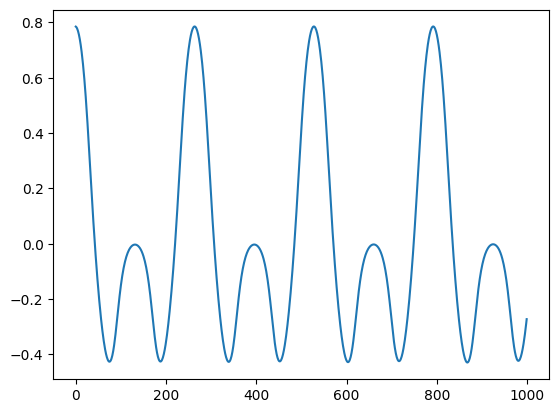

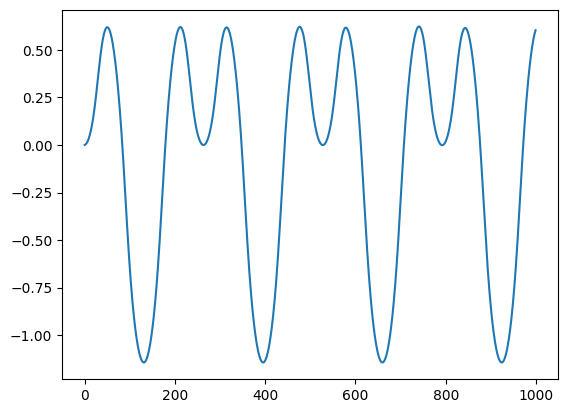

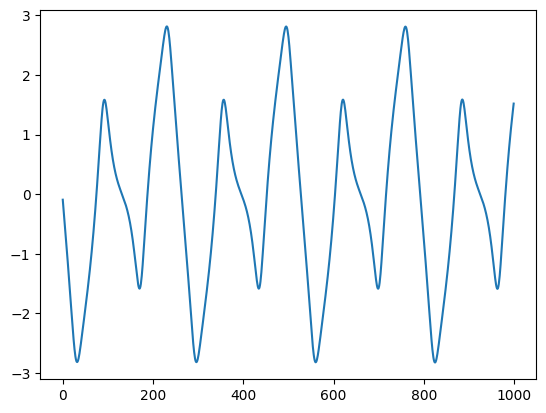

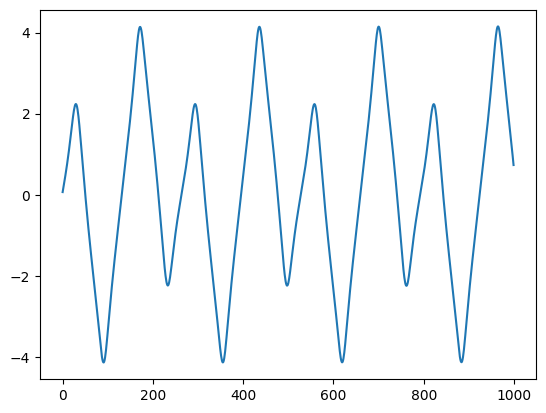

In [24]:
xp = torch.stack(xs, dim=0)
xp = xp.cpu().detach().numpy()
fig = plt.figure()
# plot = plt.plot(xp[:,:,0])

for i in range(4):
    fig = plt.figure()
    plot = plt.plot(xp[:,:,i])

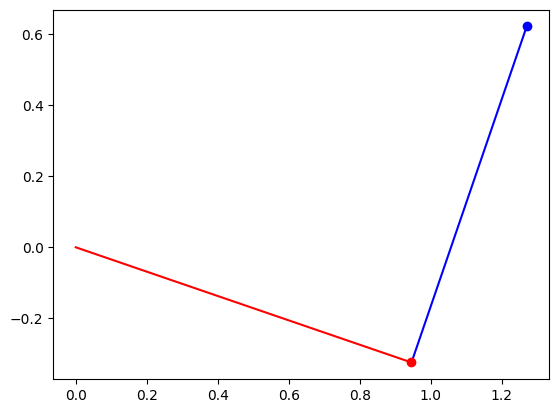

In [15]:
xp = torch.stack(xs, dim=0)
# fig = plt.figure()
# plot = plt.plot(xp[:,:,1])

# visualize pendulum at first time step, draw circles and lines
def draw_pendulum(x):
    l = 1.0  # length of the pendulum
    x1 = l * torch.sin(x[0])
    y1 = -l * torch.cos(x[0])
    x2 = x1 + l * torch.sin(x[1])
    y2 = y1 - l * torch.cos(x[1])

    plt.plot([0, x1], [0, y1], 'r-')  # first pendulum arm
    plt.plot([x1, x2], [y1, y2], 'b-')  # second pendulum arm
    plt.plot(x1, y1, 'ro')  # first pendulum mass
    plt.plot(x2, y2, 'bo')  # second pendulum mass


draw_pendulum(xp[25, 0, :])

## Single Pendulum Simulation

In [148]:
batch_size = 10  # example batch size
x0 = torch.tensor([[torch.pi / i, 0.0] for i in range(2,21)], requires_grad=True)  # initial state for each batch
t0 = 0.0  # initial time
t1 = 20.0  # final time
dt = 0.01  # time step
num_steps = int((t1 - t0) / dt)

# store traj
xs = []

for i in range(num_steps):
    t = t0 + i * dt
    
    x0 = rk4_step(lambda x: lagrangian_dynamics(x, pendulum_lagrangian, 1), x0, dt)

    xs.append(x0.clone().detach())
    if i % 100 == 0:  # print every 100 steps
        print(f"Step {i}: t = {t}")

Step 0: t = 0.0
Step 100: t = 1.0
Step 200: t = 2.0
Step 300: t = 3.0
Step 400: t = 4.0
Step 500: t = 5.0
Step 600: t = 6.0
Step 700: t = 7.0
Step 800: t = 8.0
Step 900: t = 9.0
Step 1000: t = 10.0
Step 1100: t = 11.0
Step 1200: t = 12.0
Step 1300: t = 13.0
Step 1400: t = 14.0
Step 1500: t = 15.0
Step 1600: t = 16.0
Step 1700: t = 17.0
Step 1800: t = 18.0
Step 1900: t = 19.0


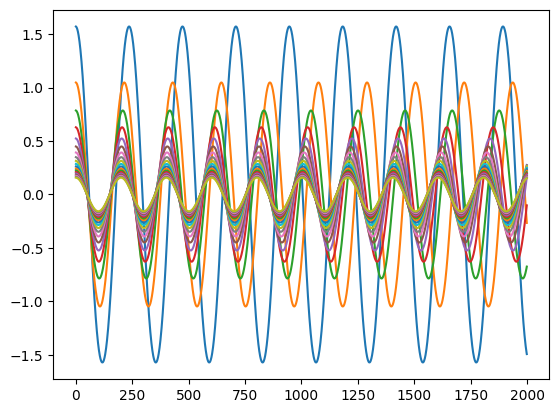

In [149]:
xp = torch.stack(xs, dim=0)
fig = plt.figure()
plot = plt.plot(xp[:,:,0])